In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
import netCDF4 as nc
orig = '/home/nld4814/scratch/run_FGRN055-era055_1939-2023/output/FGRN055_era055_1D_38901.nc'
ext  = '/home/nld4814/scratch/extend-FGRN055-era055_1939-2023_to_2025-2/output/FGRN055_era055_1D_38901.nc'
out  = '/ec/res4/scratch/nld4814/FDM_FGRN055_output/output/points/FGRN055_era055_1D_38900.nc'
for label, p in [('orig', orig), ('ext', ext), ('out', out)]:
    with nc.Dataset(p) as ds:
        print(label, len(ds.dimensions['ind_t']), ds.model_end_datetime)


orig 30803 2023-12-31T21:00:00
ext 31534 2025-12-31T21:00:00
out 31534 2025-12-31T21:00:00


In [34]:


ds_orig = xr.open_dataset('/home/nld4814/scratch/run_FGRN055-era055_1939-2023/output/FGRN055_era055_1D_38902.nc')
ds_extend = xr.open_dataset('/home/nld4814/scratch/extend-FGRN055-era055_1939-2023_to_2025-2/output/FGRN055_era055_1D_38902.nc')
ds_combined = xr.open_dataset('/ec/res4/scratch/nld4814/FDM_FGRN055_output/output/points/FGRN055_era055_1D_38900.nc')

timestamps = pd.date_range(start=ds_orig.model_start_datetime, periods=len(ds_orig.ind_t), freq=f'1D')

ds_orig["ind_t"] = timestamps

timestamps = pd.date_range(start=ds_extend.model_start_datetime, periods=len(ds_extend.ind_t), freq=f'1D')

ds_extend["ind_t"] = timestamps
ds_combined["ind_t"] = timestamps

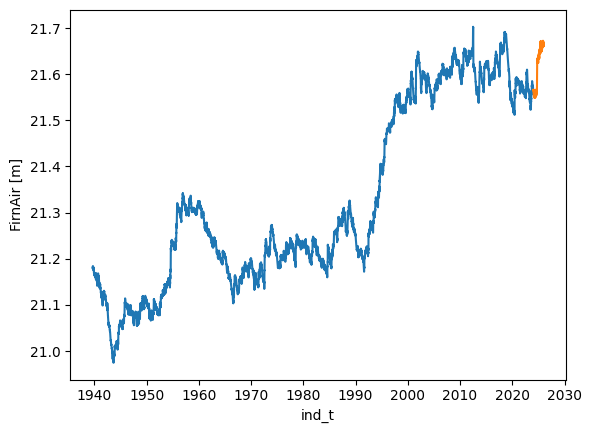

In [35]:
ds_orig.FirnAir.plot()
ds_extend.FirnAir.plot()

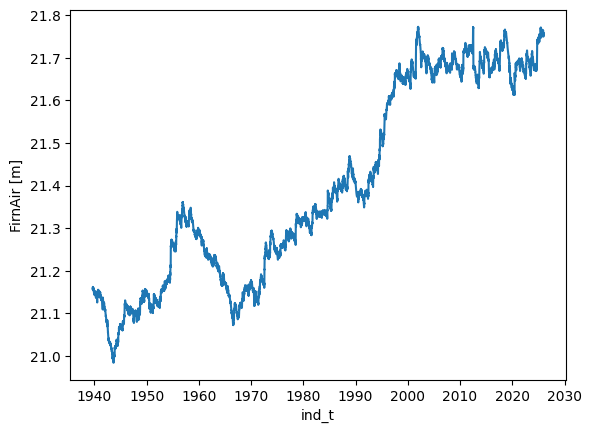

In [30]:
ds_combined.FirnAir.plot()